In [1]:
from sentence_transformers import SentenceTransformer
from sentence_transformers.util import cos_sim


import torch

import torch.nn.functional as F

from scipy.stats import spearmanr

model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
import nltk

from nltk.corpus import wordnet as wn

import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

from wordfreq import top_n_list



c:\Users\marco\Tesi_2025-26-La-Geometria-degli-Embedding-di-un-LLm\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2429.70it/s]


In [3]:
#filtro per ottenere solo parole alfabetiche
vocab = [
    w for w in top_n_list("en", 120000)
    if w.isalpha()
    if len(w)  >= 3
]

In [4]:
vocab_100k = vocab[:100000]

In [2]:
#per aprire vocab 100k
with open("vocab_100k.txt", "r", encoding="utf-8") as f:
    vocab_100k = [line.strip() for line in f]

In [5]:
#calcolo gli embedding una sola volta grazie a vocab 100kk
embeddings_matrix = model.encode(
    vocab_100k,
    convert_to_tensor=True,
    batch_size=128,
    show_progress_bar=True
)

print("Embedding creati:", len(embeddings_matrix))

Batches:   2%|▏         | 15/782 [00:02<02:32,  5.02it/s]


KeyboardInterrupt: 

In [17]:
# salvo La matrice per non ricalcolare gli embedding ogni volta
torch.save(
    {
        "vocab": vocab_100k,
        "embeddings": embeddings_matrix.cpu()
    },
    "sbert_vocab_100k.pt"
)

print("Salvataggio completato!")

Salvataggio completato!


In [3]:
#codice da eseguire per avere la matrice di embedding
data = torch.load("sbert_vocab_100k.pt")

vocab_100k = data["vocab"]
embeddings_matrix = data["embeddings"]

In [4]:
#associo parola a embedding perchè prima ho la matrice
embeddings = {
    word: embedding
    for word, embedding in zip(vocab_100k, embeddings_matrix)
}

print("Embedding creati:", len(embeddings))

Embedding creati: 100000


In [20]:
#carico i dataset
Analogie_df = pd.read_csv("Analogie.csv")

In [6]:
#anche per 50k e 30k
vocab_30k = vocab_100k[:30000]
vocab_50k = vocab_100k[:50000]

embeddings_30k = embeddings_matrix[:30000]
embeddings_50k = embeddings_matrix[:50000]

print(len(embeddings_30k))
print(len(embeddings_50k))

30000
50000


In [7]:
#anche per loro i dizionari
embeddings_dict_30k = {
    word: embedding
    for word, embedding in zip(vocab_30k, embeddings_30k)
}

embeddings_dict_50k = {
    word: embedding
    for word, embedding in zip(vocab_50k, embeddings_50k)
}

In [21]:
print(Analogie_df.head())
Analogie_df["category"].value_counts()

  category            a             b            c             d
0  plurale        river        rivers      science      sciences
1  plurale      science      sciences        album        albums
2  plurale        album        albums  application  applications
3  plurale  application  applications         area         areas
4  plurale         area         areas          car          cars


category
plurale           35
genere            35
capitale_paese    35
avverbi           35
Name: count, dtype: int64

In [22]:
#assegno embedding alle tre parole dell'analogia per creare il vettore risultante
a, b, c, d = Analogie_df.iloc[0][["a", "b", "c", "d"]]

vec_a = embeddings[a]
vec_b = embeddings[b]
vec_c = embeddings[c]

result = vec_b - vec_a + vec_c

In [10]:

candidate_vocab = vocab_100k[:30000]

best_word = None
best_score = -1

for word in candidate_vocab:
    #escludiamo le parole già presenti nell'analogia
    if word in [a, b, c]:
        continue

    score = F.cosine_similarity(
        result.unsqueeze(0),
        embeddings[word].unsqueeze(0)
    ).item()

    if score > best_score:
        best_score = score
        best_word = word

print("Analogia:", f"{a} : {b} :: {c} : {d}")
print("Predetto:", best_word)
print("Atteso:", d)
print("Cosine similarity:", best_score)

Analogia: river : rivers :: science : sciences
Predetto: scientific
Atteso: sciences
Cosine similarity: 0.790209174156189


In [23]:
#funzione in generale per testare tutte le analogie
def test_analogy(a, b, c, d, candidate_vocab):
    #in input le 4 parole dell'analogie e il vocabolario di riferirimento (100,50,30k)
    # calcolo del vettore risultante
    result = embeddings[b] - embeddings[a] + embeddings[c]
    
    # cerco la parola più vicina
    best_word = None
    best_score = -1
    
    for word in candidate_vocab:
        
        # escludiamo le parole già presenti nell'analogia
        if word in [a, b, c]:
            continue
        
        score = F.cosine_similarity(
            result.unsqueeze(0),
            embeddings[word].unsqueeze(0)
        ).item()
        
        if score > best_score:
            best_score = score
            best_word = word
    
    # verifico se la risposta è corretta
    correct = (best_word == d)
    
    return best_word, best_score, correct

In [24]:
#risultati per lista 30k
#creo lista di risultati
results_30k = []

for _, row in Analogie_df.iterrows():

    predicted, score, correct = test_analogy(
        row["a"],
        row["b"],
        row["c"],
        row["d"],
        vocab_30k
    )

    results_30k.append({
        "category": row["category"],
        "a": row["a"],
        "b": row["b"],
        "c": row["c"],
        "d": row["d"],
        "predicted": predicted,
        "cosine_similarity": score,
        "correct": correct
    })

df_risultati_30k = pd.DataFrame(results_30k)

In [25]:
print(df_risultati_30k.head())
print(f"\n{len(results_30k)}")
print(f"\n{df_risultati_30k.tail()}")

  category            a             b            c             d  \
0  plurale        river        rivers      science      sciences   
1  plurale      science      sciences        album        albums   
2  plurale        album        albums  application  applications   
3  plurale  application  applications         area         areas   
4  plurale         area         areas          car          cars   

      predicted  cosine_similarity  correct  
0    scientific           0.790209    False  
1        albums           0.745852     True  
2  applications           0.848078     True  
3         areas           0.868889     True  
4          cars           0.871389     True  

140

    category          a            b           c             d   predicted  \
135  avverbi    obvious    obviously      actual      actually    actually   
136  avverbi   physical   physically  additional  additionally       extra   
137  avverbi  political  politically    apparent    apparently   evidenced 

In [26]:
#per i 50k
results_50k = []

for _, row in Analogie_df.iterrows():

    predicted, score, correct = test_analogy(
        row["a"],
        row["b"],
        row["c"],
        row["d"],
        vocab_50k
    )

    results_50k.append({
        "category": row["category"],
        "a": row["a"],
        "b": row["b"],
        "c": row["c"],
        "d": row["d"],
        "predicted": predicted,
        "cosine_similarity": score,
        "correct": correct
    })

df_risultati_50k = pd.DataFrame(results_50k)

In [27]:
print(df_risultati_50k.head())

  category            a             b            c             d  \
0  plurale        river        rivers      science      sciences   
1  plurale      science      sciences        album        albums   
2  plurale        album        albums  application  applications   
3  plurale  application  applications         area         areas   
4  plurale         area         areas          car          cars   

      predicted  cosine_similarity  correct  
0    scientific           0.790209    False  
1        albums           0.745852     True  
2  applications           0.848078     True  
3         areas           0.868889     True  
4          cars           0.871389     True  


In [28]:
#per i 100k
results_100k = []

for _, row in Analogie_df.iterrows():

    predicted, score, correct = test_analogy(
        row["a"],
        row["b"],
        row["c"],
        row["d"],
        vocab_100k
    )

    results_100k.append({
        "category": row["category"],
        "a": row["a"],
        "b": row["b"],
        "c": row["c"],
        "d": row["d"],
        "predicted": predicted,
        "cosine_similarity": score,
        "correct": correct
    })

df_risultati_100k = pd.DataFrame(results_100k)

In [29]:
print(df_risultati_100k.head())

  category            a             b            c             d  \
0  plurale        river        rivers      science      sciences   
1  plurale      science      sciences        album        albums   
2  plurale        album        albums  application  applications   
3  plurale  application  applications         area         areas   
4  plurale         area         areas          car          cars   

      predicted  cosine_similarity  correct  
0    scientific           0.790209    False  
1        albums           0.745852     True  
2  applications           0.848078     True  
3         areas           0.868889     True  
4          cars           0.871389     True  


In [30]:
#salvo i dataframe
df_risultati_30k.to_csv("df_risultati_30k.csv", index=False)
df_risultati_50k.to_csv("df_risultati_50k.csv", index=False)
df_risultati_100k.to_csv("df_risultati_100k.csv", index=False)

In [31]:
#codice da eseguire per avere il dataframe
df_risultati_30k = pd.read_csv("df_risultati_30k.csv")
df_risultati_50k = pd.read_csv("df_risultati_50k.csv")
df_risultati_100k = pd.read_csv("df_risultati_100k.csv")

In [32]:
#calcoliamo accuracy per ogni vocab
print("Accuracy:")
print(f"30k:  {df_risultati_30k['correct'].value_counts(normalize=True)[True] * 100:.2f}%")
print(f"50k:  {df_risultati_50k['correct'].value_counts(normalize=True)[True] * 100:.2f}%")
print(f"100k: {df_risultati_100k['correct'].value_counts(normalize=True)[True] * 100:.2f}%")

Accuracy:
30k:  53.57%
50k:  52.14%
100k: 47.86%


In [33]:
#tabella accuracy distinta per ogni gruppo di analogia per ogni vocab
tabella_accuracy = pd.DataFrame({
    "30k": df_risultati_30k.groupby("category")["correct"].mean() * 100,
    "50k": df_risultati_50k.groupby("category")["correct"].mean() * 100,
    "100k": df_risultati_100k.groupby("category")["correct"].mean() * 100
})

tabella_accuracy = tabella_accuracy.round(2)

print(tabella_accuracy)

                  30k    50k   100k
category                           
avverbi         37.14  37.14  28.57
capitale_paese  62.86  62.86  62.86
genere          28.57  22.86  22.86
plurale         85.71  85.71  77.14


In [34]:
#rinomino categorie per il grafico
tabella_accuracy = tabella_accuracy.rename(index = {"avverbi" : "aggettivi_avverbi", "plurale" : "singolare_plurale"})


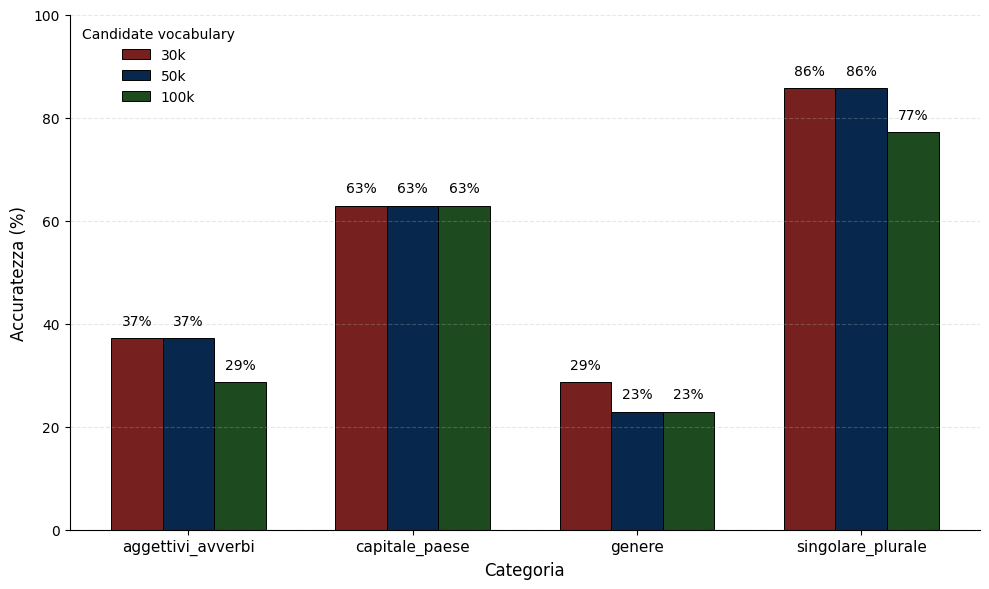

In [38]:
#provo a visualizzarli in grafici ispirati a documentazione trovata
tabella_plot = tabella_accuracy.drop(index="Totale", errors="ignore")

x = np.arange(len(tabella_plot.index))
width = 0.23

fig, ax = plt.subplots(figsize=(10, 6))

bars1 = ax.bar(
    x - width, tabella_plot["30k"], width,
    label="30k",
    color="#762020",
    edgecolor="black",
    linewidth=0.7
)

bars2 = ax.bar(
    x, tabella_plot["50k"], width,
    label="50k",
    color="#07274C",
    edgecolor="black",
    linewidth=0.7
)

bars3 = ax.bar(
    x + width, tabella_plot["100k"], width,
    label="100k",
    color="#1E4A20",
    edgecolor="black",
    linewidth=0.7
)

#Etichette delle percentuali
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 2,
            f"{height:.0f}%",
            ha="center",
            va="bottom",
            fontsize=10
        )

ax.set_xlabel("Categoria", fontsize=12)
ax.set_ylabel("Accuratezza (%)", fontsize=12)

ax.set_xticks(x)
ax.set_xticklabels(tabella_plot.index, fontsize=11)

ax.set_ylim(0, 100)
ax.set_yticks(np.arange(0, 101, 20))

#Griglia solo orizzontale
ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

#Tolgo i bordi superiore e destro
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    title="Candidate vocabulary",
    frameon=False,
    fontsize=10,
    title_fontsize=10
)

plt.tight_layout()

plt.savefig('Confronto_accuracy_esp_3.png', dpi=300)
plt.show()

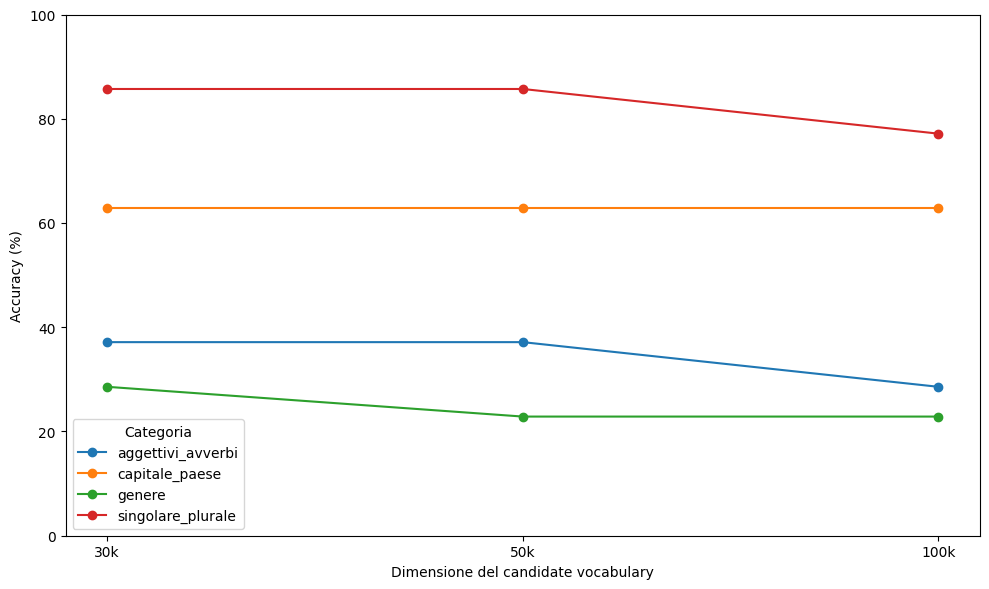

In [37]:
#secondo grafico 
plt.figure(figsize=(10, 6))

for category in tabella_plot.index:
    plt.plot(
        ["30k", "50k", "100k"],
        tabella_plot.loc[category, ["30k", "50k", "100k"]],
        marker="o",
        label=category
    )

plt.xlabel("Dimensione del candidate vocabulary")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)

plt.legend(title="Categoria")
plt.tight_layout()
plt.show()